In [375]:
from pathlib import Path
from matplotlib import pyplot
from matplotlib import gridspec
from PIL import Image
from torch import nn
from os import listdir, walk
from os.path import isfile, join

import numpy as np
import requests
import pickle
import gzip
import torch
import torch.nn as nn
import torch.optim as optimizer
import math
import torchvision
import sklearn
import pandas as pd

(499, 375)


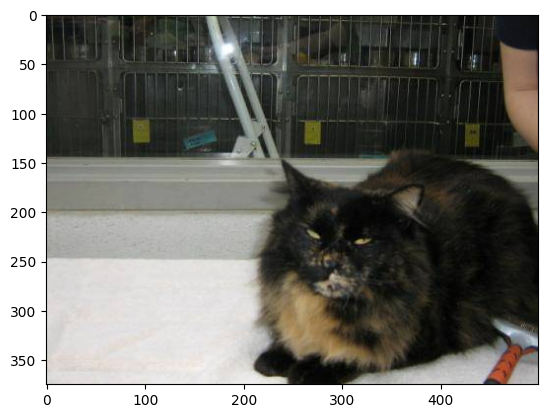

In [348]:
DATA_PATH = Path("../../data")
PATH = DATA_PATH / "cnd"

img = Image.open(PATH/"training_set/cats/cat.150.jpg")
print(img.size)

pyplot.imshow(img)
pyplot.show()

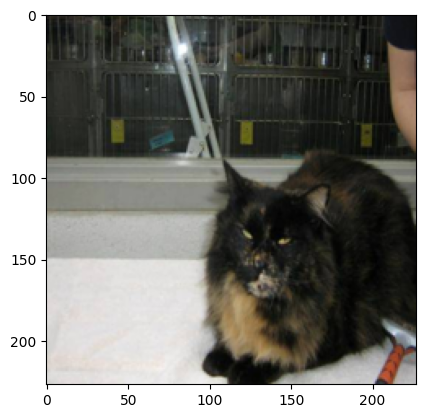

In [258]:
def scale_resize_image(image):
    resize_transform = torchvision.transforms.Resize((227, 227), interpolation=torchvision.transforms.InterpolationMode.BICUBIC)
    image = np.array(resize_transform.forward(image))
    return image

def get_valid_image(path):
    img = Image.open(path)
    val = scale_resize_image(img)
    val = np.moveaxis(val, -1, 0)
    # val = np.expand_dims(val, 0)
    return val

val = scale_resize_image(img)
pyplot.imshow(val)
pyplot.show()

In [112]:
test = np.moveaxis(val, -1, 0) # < - needed to move the channel to the first spot
test = np.expand_dims(test, 0)
print(test.shape)

(1, 3, 227, 227)


In [117]:
print(get_valid_image(PATH/"training_set/cats/cat.150.jpg").shape)

(1, 3, 227, 227)


In [259]:
dataset_X = []
dataset_Y = []
for f in listdir(PATH/"training_set/cats"):
    if isfile(join(PATH/"training_set/cats", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/cats"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((1,0)).to(torch.float32))
for f in listdir(PATH/"training_set/dogs"):
    if isfile(join(PATH/"training_set/dogs", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/dogs"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((0,1)).to(torch.float32))

In [303]:
df = pd.DataFrame(data={"image":dataset_X, "label":dataset_Y})

In [307]:
df = df.sample(frac=1).reset_index(drop=True)

In [308]:
df.head()

,image,label
0,"[[[tensor(163.), tensor(163.), tensor(164.), t...","[tensor(0.), tensor(1.)]"
1,"[[[tensor(135.), tensor(161.), tensor(174.), t...","[tensor(1.), tensor(0.)]"
2,"[[[tensor(232.), tensor(232.), tensor(232.), t...","[tensor(0.), tensor(1.)]"
3,"[[[tensor(180.), tensor(180.), tensor(180.), t...","[tensor(0.), tensor(1.)]"
4,"[[[tensor(224.), tensor(212.), tensor(179.), t...","[tensor(0.), tensor(1.)]"


In [260]:
cnn1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4)

In [261]:
val.shape

(227, 227, 3)

In [294]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4)
        self.conv2 = nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 2)

        #Transforms
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.dropout = nn.Dropout(p=0.5)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x))
        x = self.maxpool1(x)
        # Layer 2
        x = nn.functional.relu(self.conv2(x))
        x = self.maxpool2(x)
        # Layer 3
        x = nn.functional.relu(self.conv3(x))
        x = nn.functional.relu(self.conv4(x))
        x = nn.functional.relu(self.conv5(x))
        x = self.maxpool3(x)
        x = torch.flatten(x)
        # Layer 4
        x = self.dropout(nn.functional.relu(self.fc1(x)))
        x = self.dropout(nn.functional.relu(self.fc2(x)))
        x = self.fc3(x)

        # Apply softmax to x
        output = torch.softmax(x,0)

        return output

In [299]:
class CustomNet(nn.Module):
    def __init__(self):
        super(CustomNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=6, padding=1, stride=2)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=6, padding=1, stride=5)

        self.avgpool1 = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.avgpool2 = nn.AvgPool2d(kernel_size=4, stride=3, padding=1)

        self.fc1 = nn.Linear(in_features=1176, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=2)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x)) # 227x227x3 -> 112x112x12
        x = self.avgpool1(x) #112x112x12 -> 112x112x12

        # Layer 2
        x = nn.functional.relu(self.conv2(x)) # 112x112x12 -> 22x22x24
        x = self.avgpool2(x)
        x = torch.flatten(x)

        # Layer 3
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        output = torch.softmax(x,0)

        return output

In [313]:
X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)

6642    [[[tensor(78.), tensor(68.), tensor(58.), tens...
6359    [[[tensor(40.), tensor(39.), tensor(43.), tens...
6852    [[[tensor(48.), tensor(48.), tensor(48.), tens...
4516    [[[tensor(129.), tensor(129.), tensor(129.), t...
1588    [[[tensor(10.), tensor(11.), tensor(11.), tens...
                              ...                        
3441    [[[tensor(63.), tensor(63.), tensor(63.), tens...
1344    [[[tensor(89.), tensor(91.), tensor(90.), tens...
4623    [[[tensor(183.), tensor(168.), tensor(153.), t...
7293    [[[tensor(99.), tensor(100.), tensor(124.), te...
1289    [[[tensor(35.), tensor(36.), tensor(37.), tens...
Name: image, Length: 6404, dtype: object

In [339]:
net = AlexNet()
# net = CustomNet()
criterion = nn.CrossEntropyLoss()
# opt = optimizer.SGD(net.parameters(),lr=0.001)
opt = optimizer.SGD(net.parameters(),lr=0.001, momentum=0.1)

# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(dataset_X, dataset_Y, test_size=0.2, random_state=10, shuffle=True)

validation_loss = []
training_loss = []
for epoch in range(10):
    t_loss = 0
    running_loss = 0
    for i, row in enumerate(X_train):
        opt.zero_grad()

        outputs = net(row)
        loss = criterion(outputs, Y_train[i])
        loss.backward()
        opt.step()
        # print(outputs, Y_train[i])

        # print statistics
        # with torch.no_grad():
        #     outputs = AlexNet(row)
        #     loss = criterion(outputs, Y_train[i])
        running_loss += loss.item()
        t_loss += loss.item()
        # if i == 10:
        #     break
        if i % 500 == 499:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')
            print(outputs, Y_train[i])
            running_loss = 0.0
    training_loss.append(t_loss/i)
    with torch.no_grad():
        val = 0
        for i, row in enumerate(X_valid):
            outputs = net(row)
            loss = criterion(outputs, Y_valid[i])
            val += loss.item()
        validation_loss.append(val/i)
        

[1,   500] loss: 0.734
tensor([0.4105, 0.5895], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1000] loss: 0.701
tensor([0.4865, 0.5135], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  1500] loss: 0.697
tensor([0.4943, 0.5057], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  2000] loss: 0.696
tensor([0.3345, 0.6655], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  2500] loss: 0.695
tensor([0.4858, 0.5142], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3000] loss: 0.691
tensor([0.3897, 0.6103], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  3500] loss: 0.696
tensor([0.5124, 0.4876], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  4000] loss: 0.693
tensor([0.4744, 0.5256], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  4500] loss: 0.690
tensor([0.2970, 0.7030], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5000] loss: 0.696
tensor([0.4256, 0.5744], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  5500] loss: 0.694
tensor([0.4888, 0.5112], grad_fn=<SoftmaxBackwa

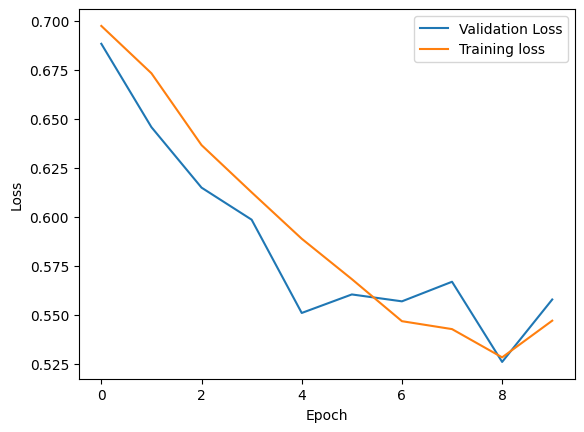

In [341]:
pyplot.plot(validation_loss, label="Validation Loss")
pyplot.plot(training_loss, label="Training loss")
pyplot.ylabel("Loss")
pyplot.xlabel("Epoch")
pyplot.legend()

In [345]:
save_path = './AlexNET.pth'
torch.save(net.state_dict(), PATH)

In [390]:
model_path = './AlexNET.pth'
new_net = AlexNet()
new_net.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [359]:
X_test = []
Y_test = []
path_test = []
for f in listdir(PATH/"test_set/cats"):
    if isfile(join(PATH/"test_set/cats", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/cats"/f)).to(torch.float32))
        Y_test.append(torch.tensor((1,0)).to(torch.float32))
        path_test.append(PATH/"test_set/cats"/f)
for f in listdir(PATH/"test_set/dogs"):
    if isfile(join(PATH/"test_set/dogs", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/dogs"/f)).to(torch.float32))
        Y_test.append(torch.tensor((0,1)).to(torch.float32))
        path_test.append(PATH/"test_set/dogs"/f)

df_test = pd.DataFrame(data={"image":X_test, "label":Y_test, "path":path_test})
df_test = df_test.sample(frac=1).reset_index(drop=True)

/Users/jgrguric/Repos/ml_tut/ML-101/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


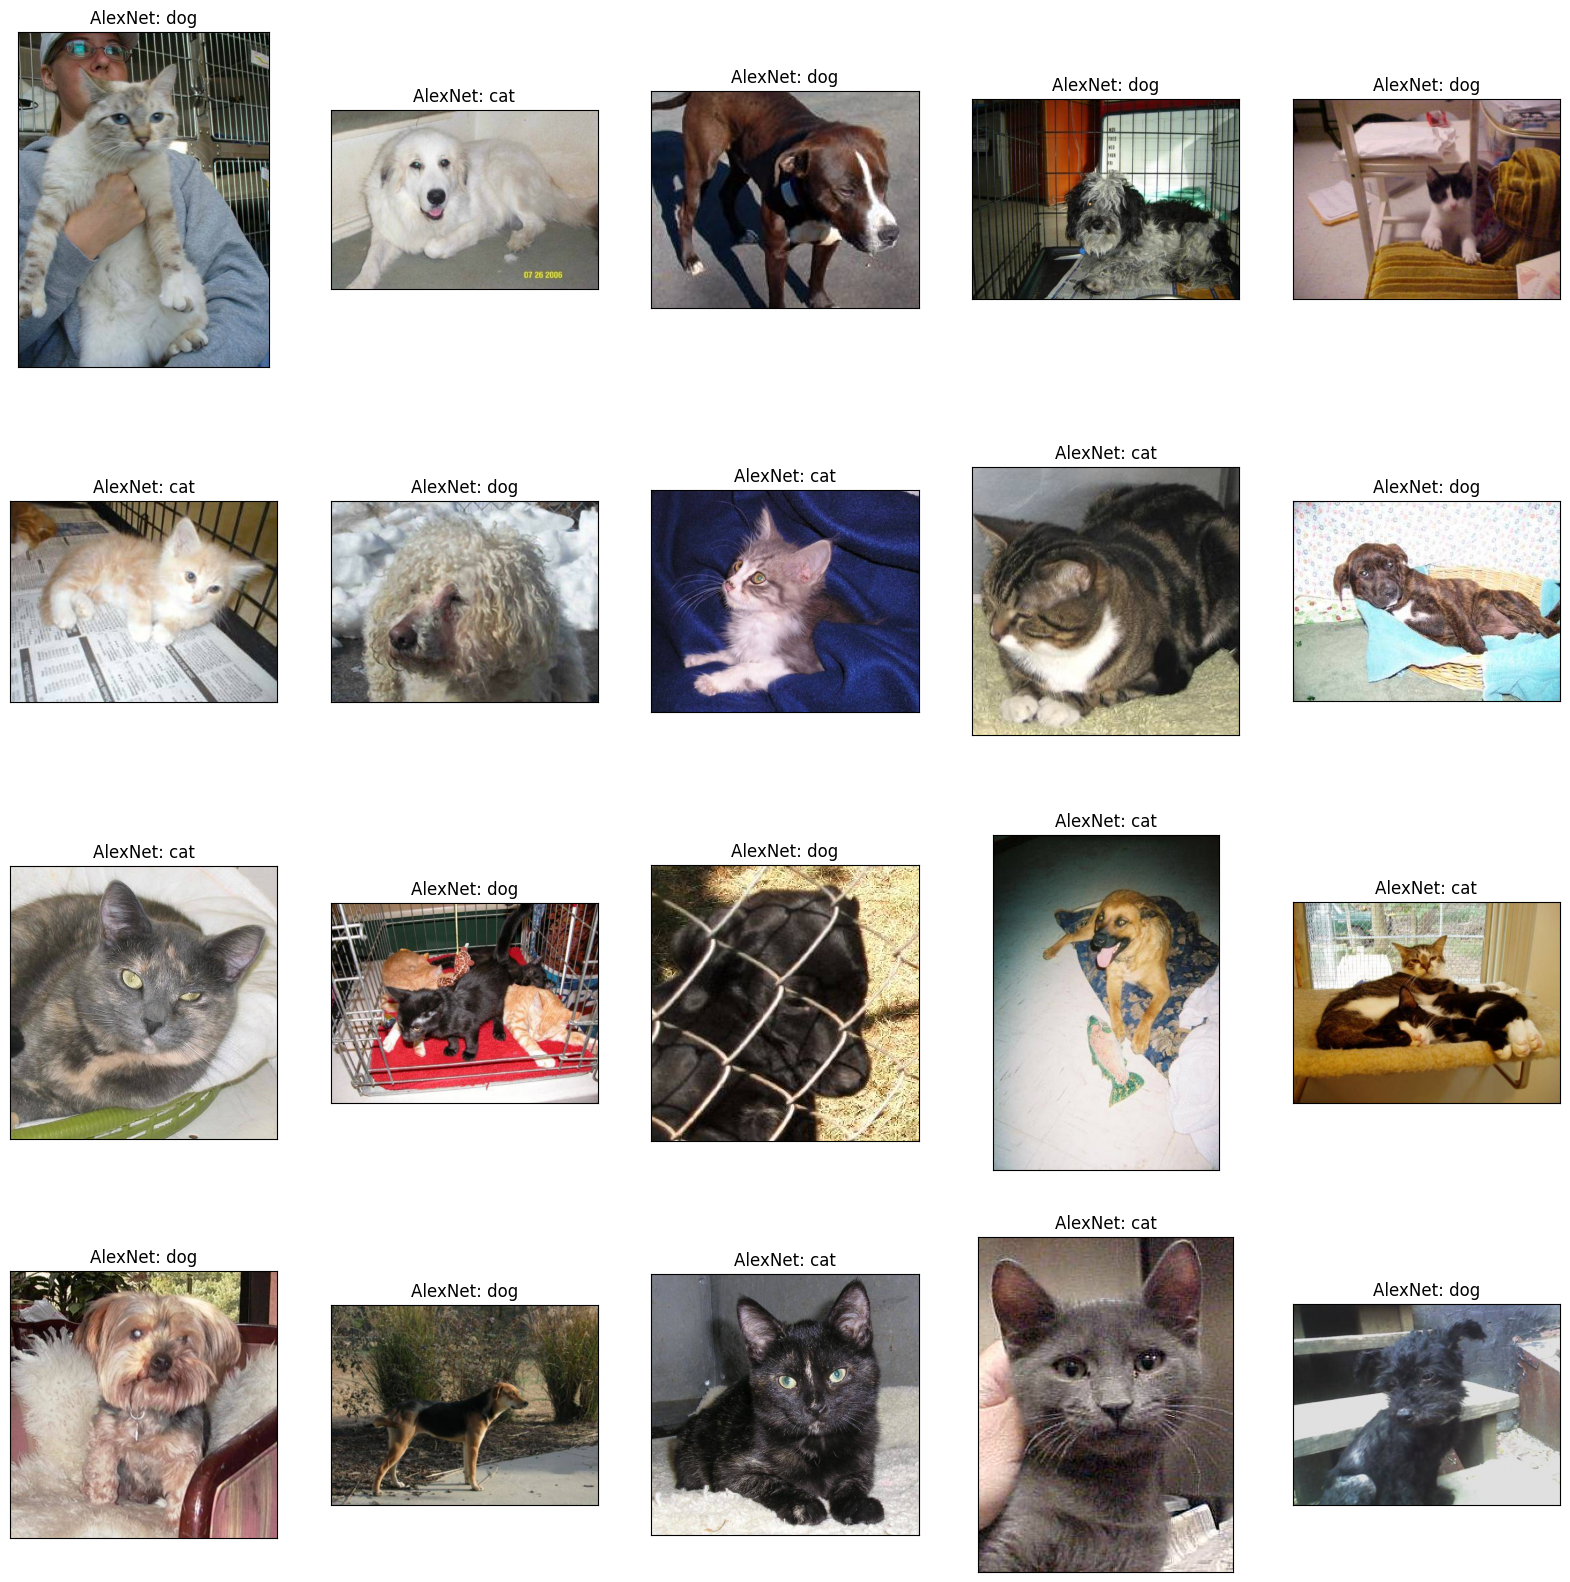

In [391]:
samples = df_test.sample(20)

x = []
title = []
for index, sample in samples.iterrows():
    x.append(sample.path)
    title.append("AlexNet: dog") if torch.argmax(new_net(sample.image)) else title.append("AlexNet: cat")
    

grid_size_x = math.floor((len(x))**(1/2))
grid_size_y = math.ceil((len(x))/grid_size_x)  
gs = gridspec.GridSpec(grid_size_x, grid_size_y)   
# gs.update(bottom=0.1)
# gs.update(top=0.55)
fig = pyplot.figure(constrained_layout = True)
fig.set_figwidth(20)
fig.set_figheight(20)
# Process image
for i, im in enumerate(x):
    ax = fig.add_subplot(gs[(i)//grid_size_y, (i)%grid_size_y])
    ax.imshow(Image.open(im))
    ax.set_title(title[i])
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)



pyplot.show()

In [342]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for i, data in enumerate(X_valid):
        # calculate outputs by running images through the network
        outputs = net(data)
        # the class with the highest energy is what we choose as prediction
        predicted = torch.argmax(outputs)
        total += 1
        correct += 1 if predicted == torch.argmax(Y_valid[i]) else 0
print(f"Accuracy is {correct/total}")

Accuracy is 0.7389131792629606


In [344]:
with torch.no_grad():
    outputs = []
    for i in range(10):
        outputs.append(net(X_valid[i]))
print(outputs)
print(Y_valid[:10])
        

[tensor([4.1903e-04, 9.9958e-01]), tensor([0.2266, 0.7734]), tensor([0.9498, 0.0502]), tensor([1.0000e+00, 1.4818e-07]), tensor([0.9910, 0.0090]), tensor([1.0000e+00, 1.5974e-06]), tensor([5.1005e-04, 9.9949e-01]), tensor([0.9964, 0.0036]), tensor([0.4613, 0.5387]), tensor([2.9912e-08, 1.0000e+00])]
[tensor([0., 1.]), tensor([0., 1.]), tensor([0., 1.]), tensor([1., 0.]), tensor([1., 0.]), tensor([1., 0.]), tensor([0., 1.]), tensor([1., 0.]), tensor([1., 0.]), tensor([0., 1.])]
